### 3.Fine-tuning

* Fine-tuning is not always used in GenAI because it needs large data, high cost, powerful GPUs, and more training time.
* Most tasks can already be solved using Prompt Engineering, RAG, and system instructions without retraining the model.

## LangChain

### Why LangChain? Building Smarter AI Workflows

* Building AI apps with native SDKs is difficult because every provider uses different code, leading to "vendor lock-in" and high complexity. LangChain fixes this by offering a unified, LEGO-like framework that simplifies complex workflows.

The Key Benefits:

* **Unified Code:** Swap between models (GPT, Gemini, Groq) by changing only 1–2 lines of code instead of rewriting the entire application.

* **Built-in Memory:** Easily makes "stateless" LLMs stateful so they remember conversation history.

* **Real-Time Data:** Bypasses model cutoff dates by connecting to web search tools.

* **Proprietary Data:** Uses RAG (Retrieval-Augmented Generation) to let AI work with your private, non-public information with minimal effort.

### What is LangChain?
 At its core, LangChain is a framework designed to simplify the creation of LLM workflows. Think of it like LEGO blocks for AI.
 You have different pieces—memory, data connectors, and the models themselves—and LangChain allows you to "chain" these sub-tasks together to solve complex problems.
 One of the most important concepts in this framework is LCEL (LangChain Expression Language), which allows every application you build to be a structured, manageable chain.

### The 3 Major Problems LangChain Solves

 Why not just use a standard SDK? While individual SDKs (like those from OpenAI or Google) are powerful, they have limitations that LangChain is designed to overcome:

1. The "State" Problem (Memory)
By nature, LLMs are stateless. This means they cannot remember previous parts of a conversation on their own. Each query is like meeting the AI for the first time.

* The SDK approach: You have to manually write code to store and feed past conversation history back into the model.

* The LangChain approach: It makes workflows "stateful" with minimal effort, handling the memory for you so the AI remembers context.

2. The "Cutoff" Problem (Real-time Info)
* Every LLM has a cutoff date—the point where its training data ends. If you ask a model about news from this morning, it won't know the answer.

* The Solution: LangChain allows you to add Tools (like a web search tool). This lets the model look up information beyond its training data to provide current answers.

3. The "Unified Approach" (Interchangeability)
* Usually, if you want to switch from GPT to Gemini or Mistral, you have to rewrite a significant portion of your code because their SDKs are different.

* With LangChain, the way you interact with an LLM remains the same irrespective of the API.

* The code stays consistent; you often only need to change 1 or 2 lines of code to swap out your "Client" or model provider.

### From Simple Chains to Complex Graphs

we looked at why LangChain is a game-changer. Today, let’s dive into the components that make it work and the different tools in the ecosystem that help you go from a simple prompt to a complex, production-ready AI agent.

1. The Anatomy of a Simple Chain
To build a basic chain, you need three primary ingredients. Think of this as the "Standard Formula" for an LLM application:

* **Chain = Prompt Template | Model | Output Parser (Optional)**

**Prompt Templates:** Instead of hardcoding text, templates allow you to create dynamic inputs.

**Model:** This is the brain (like Gemini, GPT, or Mistral).

**Parser:** This cleans up the AI's response into a format your code can easily read (like JSON).

2. Choosing Your "Mode"
LangChain has evolved. It’s important to know which model type you are working with:

**Regular (Deprecated):** These older models only took a single string as input.

**Chat Models:** The current standard. They take a list of messages as input, allowing for a conversational flow.

**Embedding Models:** These are specifically used for RAG (Retrieval-Augmented Generation) to help the AI "read" your private data.


3. The LangChain "Family"

One of the most interesting things I learned is that LangChain isn't just one library; it’s a whole suite of tools tailored for different levels of complexity:

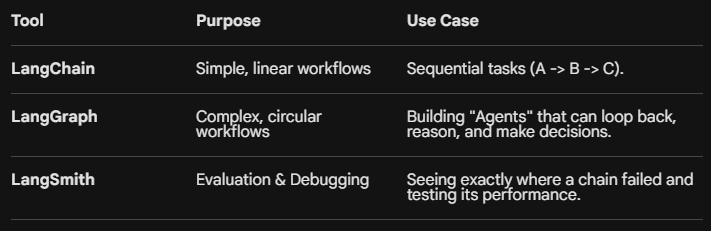

4. How to Actually Build It (The Workflow)
If you're ready to start coding, the process follows a very logical path. Using the Google Gemini integration as an example, here is the mental checklist:

* **Install the Integration:** Download the specific package for the model you want (e.g., langchain-google-genai).

* **Import the Model:** Bring the Chat Model into your script.

* **Assign the API Key:** Securely connect to the provider.

* **Create & Invoke:** Define your prompt, send it to the LLM, and use .invoke() to get the response.

Why "Integrations" Matter

LangChain uses a Shared Resource approach. By going to the "Integrations" section of the documentation, you can see examples for dozens of models and tools. This makes it incredibly easy to experiment—you aren't locked into one provider.

# [LangChain Doc](https://docs.langchain.com/)

**Google Gemini + LangChain**: [Google Gemini link](https://docs.langchain.com/oss/python/integrations/chat/google_generative_ai)
* To start building, check out the official ChatGoogleGenerativeAI documentation.
* This guide provides the exact code to connect Gemini to LangChain, including how to handle multimodal inputs like images and video, and how to use Gemini’s powerful "tool calling" features for more advanced AI applications.

In [2]:
# Install the core LangChain package silently and update to the latest version.
!pip install -qU langchain

In [3]:
#Create a client of Gemini -Chatmodels
!pip install -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.5 MB/s eta 0:00:00


In [4]:
# import
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
# Import os for environment variables and google.colab for secure API key access.
import os
from google.colab import userdata

In [7]:
# Securely retrieve the API key and set it as an environment variable.
gem = userdata.get('gemini_key')
os.environ['GEMINI_API_KEY'] = gem

In [9]:
# Initialize the Gemini model instance with the specified version.
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
)
model

ChatGoogleGenerativeAI(profile={'name': 'Gemini 2.5 Flash Lite', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash-lite', client=<google.genai.client.Client object at 0x7fdb60c6da30>, default_metadata=(), model_kwargs={})

In [13]:
# Define the message list with a system role for instructions and a human role for the input.
messages = [
    # System Prompt
    ("system","You are a helpful assistant that translates English to Telugu. Translate the user sentence."),
    # Human Prompt
    ("human", "I love programming."),
]
messages

[('system',
  'You are a helpful assistant that translates English to Telugu. Translate the user sentence.'),
 ('human', 'I love programming.')]

In [14]:
# Send the structured conversation to the model and return the translation result.
model.invoke(messages)

AIMessage(content='నేను ప్రోగ్రామింగ్ ను ప్రేమిస్తున్నాను.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e08ab-e489-7333-bcb1-168be491452c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 13, 'total_tokens': 34, 'input_token_details': {'cache_read': 0}})

In [15]:
# Extract and display only the text content from the model's response object.
response = model.invoke(messages)
response.content

'నాకు ప్రోగ్రామింగ్ అంటే చాలా ఇష్టం. (Naku programming ante chala ishtam.)'

**Observation**:

**Secure Configuration:** Using userdata.get and os.environ ensures that sensitive API keys are never hardcoded directly into the script, which is a best practice for security.

**Unified Model Interaction:** By using the ChatGoogleGenerativeAI class, LangChain provides a standardized way to interact with Gemini. This makes it easy to swap models later without changing the core logic.

**Message-Based Structure:** Unlike older "Regular" models that took simple strings, the current Chat models use a list of structured messages (System and Human) to define the AI's behavior and context.

**The Power of .invoke():** This single method is used to call the LLM and receive a response, acting as the bridge between your code and the AI model.

**Clean Data Extraction:** The .content attribute allows you to ignore metadata (like token counts or safety ratings) and retrieve only the actual text generated by the model for a cleaner user experience.

### Now we go with Groq
[Groq link](https://docs.langchain.com/oss/python/integrations/chat/groq)

In [16]:
# Install the Groq integration for LangChain to use LPU-powered models.
!pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.1 MB/s eta 0:00:00


In [18]:
# Import the ChatGroq class to interact with  Mixtral models via Groq's API.
from langchain_groq import ChatGroq

In [19]:
# Securely fetch the Groq API key and set it as an environment variable for the framework to use.
groq = userdata.get('groq_key')
os.environ['GROQ_API_KEY'] = groq

In [23]:
# Initialize the Groq model instance, demonstrating how to swap providers while keeping the code structure identical.
model = ChatGroq(
    model="openai/gpt-oss-120b",
)
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7fdb60ae3740>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fdb60ae4890>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [24]:
# Reuse the structured message list to send the same translation request to the new Groq model.
messages = [
    # System Prompt
    ("system","You are a helpful assistant that translates English to Telugu. Translate the user sentence."),
    # Human Prompt
    ("human", "I love programming."),
]
messages

[('system',
  'You are a helpful assistant that translates English to Telugu. Translate the user sentence.'),
 ('human', 'I love programming.')]

In [26]:
# Execute the task using the Groq model and retrieve the final translated text.
response = model.invoke(messages)
print(response.content)

నేను ప్రోగ్రామింగ్‌ను ప్రేమిస్తాను.


**Observation:**

 The most significant observation here is that the framework is model-agnostic. Whether you use Google’s Gemini or Groq’s  models, the structural logic of your code remains untouched:

**Consistent Workflow:** You followed the exact same steps—fetching API keys, setting environment variables, defining a message list, and calling .invoke().

**Decoupled Logic:** The prompt (messages) is separated from the model engine. This means you can write your business logic once and swap the "brain" (the model) depending on your needs for speed, cost, or accuracy.

**Standardized Output:** Every model returns a response object with a .content attribute, ensuring that your application doesn't break when you switch providers.

### Now we go with huggingFace Models
[Hugging Face link](https://docs.langchain.com/oss/python/integrations/chat/huggingface)

In [27]:
# Install the Hugging Face integration for LangChain to access open-source models like Mistral or Llama.
!pip install -qU langchain_huggingface

In [28]:
# Import the ChatHuggingFace class to integrate open-source models into your LangChain workflow.
from langchain_huggingface import ChatHuggingFace

In [29]:
# Securely fetch the Hugging Face token and set the environment variables required by the library.
hug = userdata.get('hug_face')
os.environ['HUGGINGFACEHUB_API_TOKEN'] = hug
os.environ['HF_TOKEN'] = hug

In [30]:
# Import both the chat wrapper and the endpoint to connect with open-source models hosted on Hugging Face.
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [ ]:
# Initialize the connection to a specific model hosted on Hugging Face using its repository ID.
endpoint = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-V4-Pro", # DeepSeek's 1.6T parameter MoE model
    task="text-generation"
)
endpoint

In [ ]:
# Wrap the Hugging Face endpoint into a Chat Model interface to enable structured message support.
model = ChatHuggingFace(llm=endpoint)
model

In [33]:
# The message structure remains identical, regardless of the backend model used.
messages = [
    # System Prompt: Defines the persona and task (Translation to Telugu)
    ("system","You are a helpful assistant that translates English to Telugu. Translate the user sentence."),
    # Human Prompt: The specific input to be processed
    ("human", "I love programming."),
]
messages

[('system',
  'You are a helpful assistant that translates English to Telugu. Translate the user sentence.'),
 ('human', 'I love programming.')]

In [34]:
# Final execution: Invoking the DeepSeek model via Hugging Face to get the Telugu translation.
response = model.invoke(messages)
response.content

'నాకు ప్రోగ్రామింగ్ అంటే చాలా ఇష్టం.'